# 01 — O que os dados dizem que o Sandwell não diz

Primeiro passo da fusão, com calma. A ideia toda cabe numa frase:

> **resíduo = medida real − Sandwell**

Se o resíduo é pequeno e aleatório, o Sandwell já está bom ali. Se é grande ou tem padrão, as medidas trazem informação nova.

Rode uma célula de cada vez (**Shift+Enter**) e olhe o resultado antes de passar para a próxima.

## 1. Preparar o ambiente

O notebook fica em `notebooks/`, mas o código do projeto está em `src/`. Esta célula diz ao Python onde procurar.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
print("Raiz do projeto:", RAIZ)

Raiz do projeto: /home/marcelo/PycharmProjects/hinge-line


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.processing.fusion import load_sandwell

## 2. O Sandwell

Uma grade de ~760 mil valores de anomalia ar-livre (mGal), vinda de satélite.

In [3]:
sandwell = load_sandwell()
print("latitudes:", len(sandwell.lats), " longitudes:", len(sandwell.lons))
print("valores de %.0f a %.0f mGal" % (sandwell.values.min(), sandwell.values.max()))

latitudes: 791  longitudes: 961
valores de -120 a 252 mGal


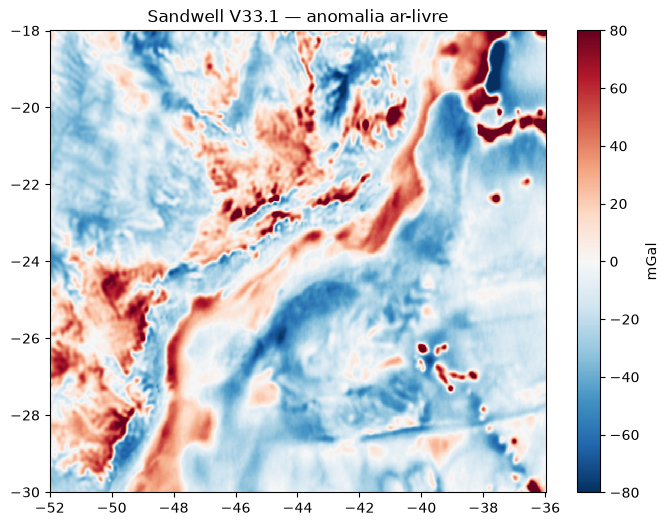

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(sandwell.lons, sandwell.lats, sandwell.values,
                   cmap="RdBu_r", vmin=-80, vmax=80, shading="auto")
fig.colorbar(im, label="mGal")
ax.set_title("Sandwell V33.1 — anomalia ar-livre")
plt.show()

In [7]:
import xarray as xr

gebco = xr.open_dataset(RAIZ / "data/raw/gebco/gebco_2026_n-18.0_s-30.0_w-52.0_e-36.0.nc")
print(gebco)

<xarray.Dataset> Size: 44MB
Dimensions:    (lat: 2880, lon: 3840)
Coordinates:
  * lat        (lat) float64 23kB -30.0 -29.99 -29.99 ... -18.01 -18.01 -18.0
  * lon        (lon) float64 31kB -52.0 -51.99 -51.99 ... -36.01 -36.01 -36.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) float32 44MB ...
Attributes: (12/37)
    comment:                         The data in the GEBCO_2026 Grid should n...
    Conventions:                     CF-1.6, ACDD-1.3
    creator_email:                   gdacc@seabed2030.org
    creator_name:                    GEBCO through the Nippon Foundation-GEBC...
    creator_type:                    International organisation
    creator_url:                     https://www.gebco.net
    ...                              ...
    project:                         Nippon Foundation - GEBCO Seabed2030 Pro...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    source:                          The GEBCO_2026 Grid is 

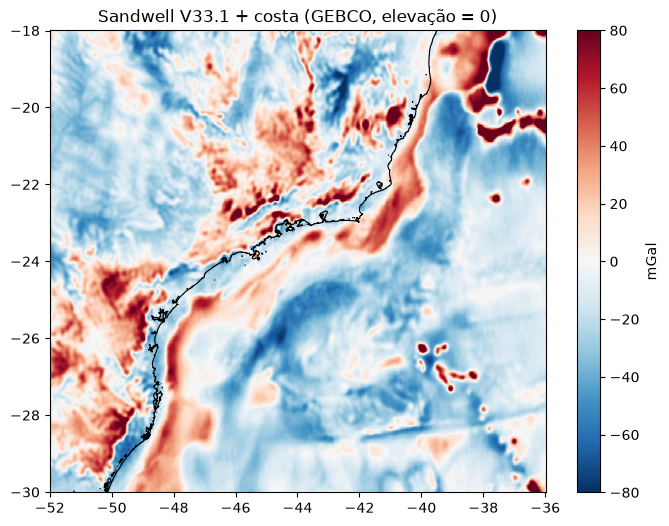

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(sandwell.lons, sandwell.lats, sandwell.values,
                   cmap="RdBu_r", vmin=-80, vmax=80, shading="auto")
ax.contour(gebco.lon, gebco.lat, gebco.elevation, levels=[0], colors="k", linewidths=0.8)
fig.colorbar(im, label="mGal")
ax.set_title("Sandwell V33.1 + costa (GEBCO, elevação = 0)")
plt.show()

In [9]:
from scipy.interpolate import RegularGridInterpolator

# pontos do GEBCO com elevação entre -30 e +30 m (a "beirada" da costa)
elev = gebco.elevation.values
lat2d, lon2d = np.meshgrid(gebco.lat.values, gebco.lon.values, indexing="ij")
costa = np.abs(elev) < 30

interp = RegularGridInterpolator((sandwell.lats, sandwell.lons), sandwell.values,
                                 bounds_error=False)
g = interp(np.column_stack([lat2d[costa], lon2d[costa]]))
g = g[~np.isnan(g)]

print("pontos:", len(g))
print("média %.1f  mediana %.1f  desvio %.1f mGal" % (g.mean(), np.median(g), g.std()))

pontos: 392377
média -14.5  mediana -19.1  desvio 24.1 mGal


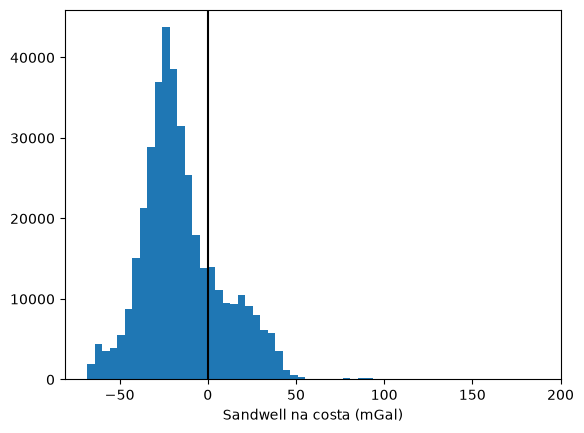

In [10]:
plt.hist(g, bins=60)
plt.axvline(0, color="k")
plt.xlabel("Sandwell na costa (mGal)")
plt.show()

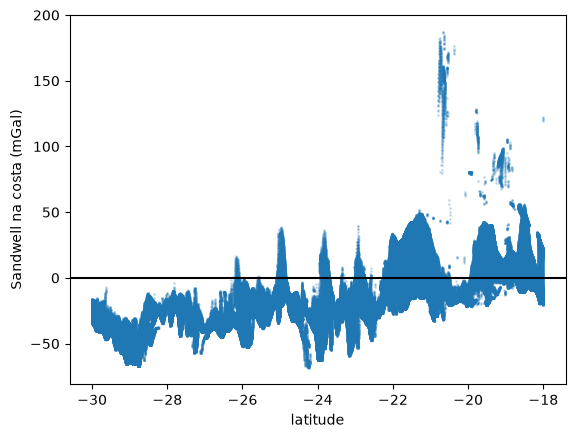

In [11]:
plt.scatter(lat2d[costa][~np.isnan(interp(np.column_stack([lat2d[costa], lon2d[costa]])))],
            g, s=1, alpha=0.2)
plt.axhline(0, color="k")
plt.xlabel("latitude")
plt.ylabel("Sandwell na costa (mGal)")
plt.show()

**Pergunta para você:** onde fica a linha de costa nesse mapa? Dá para ver só pela cor?

não


## 3. As medidas reais

Duas fontes, já preparadas nos módulos anteriores:
- **marinho**: navios (política `ok`)
- **terrestre**: estações da CPRM e da RGFB

A função abaixo junta tudo e já calcula o resíduo em cada ponto.

In [12]:
from src.processing.fusion import build_observations

obs, info = build_observations("ok", "add", sandwell)
obs[["source", "lat", "lon", "fa", "sandwell", "r"]].head()

,source,lat,lon,fa,sandwell,r
0,marine,-23.58757,-36.0037,-12.061929,-3.927585,-8.134344
1,marine,-23.58632,-36.0204,-12.461926,-4.546630,-7.915297
2,marine,-23.58505,-36.0370,-12.361924,-4.801462,-7.560462
3,marine,-23.58374,-36.0536,-12.461922,-4.794209,-7.667713
4,marine,-23.58247,-36.0702,-11.861919,-4.781776,-7.080143


Colunas: `fa` = medida real, `sandwell` = valor do Sandwell no mesmo ponto, `r` = diferença entre os dois.

In [13]:
obs["source"].value_counts()

source
marine    64565
CPRM       2816
RGFB        107
Name: count, dtype: int64

## 4. O tamanho do resíduo, por fonte

In [14]:
obs.groupby("source")["r"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
CPRM,2816.0,-6.3,14.0,-58.1,-15.1,-6.6,2.0,61.2
RGFB,107.0,-3.8,12.7,-66.4,-8.4,-2.2,3.0,42.2
marine,64565.0,-0.0,3.5,-54.0,-1.2,0.1,1.2,59.7


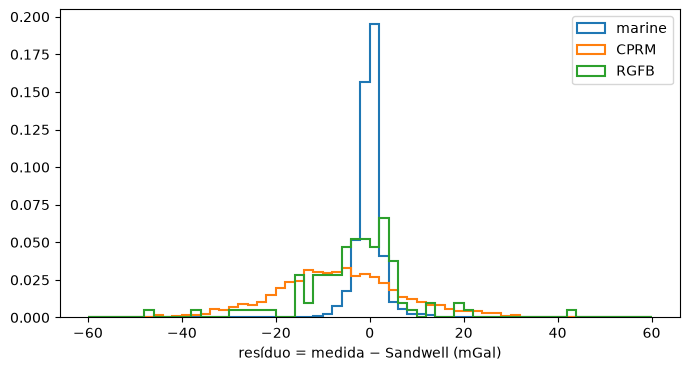

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for fonte in ["marine", "CPRM", "RGFB"]:
    r = obs.loc[obs["source"] == fonte, "r"]
    ax.hist(r, bins=np.arange(-60, 61, 2), histtype="step", density=True, label=fonte, lw=1.5)
ax.set_xlabel("resíduo = medida − Sandwell (mGal)")
ax.legend()
plt.show()

**Para observar:**
- O histograma do marinho é estreito: no mar, navio e satélite concordam em poucos mGal.
- Os terrestres são bem mais largos: em terra, o Sandwell erra bastante.

Guarde essa diferença: ela é o motivo de o `fusion.py` tratar terra e mar separadamente.

## 5. Onde estão os resíduos grandes?

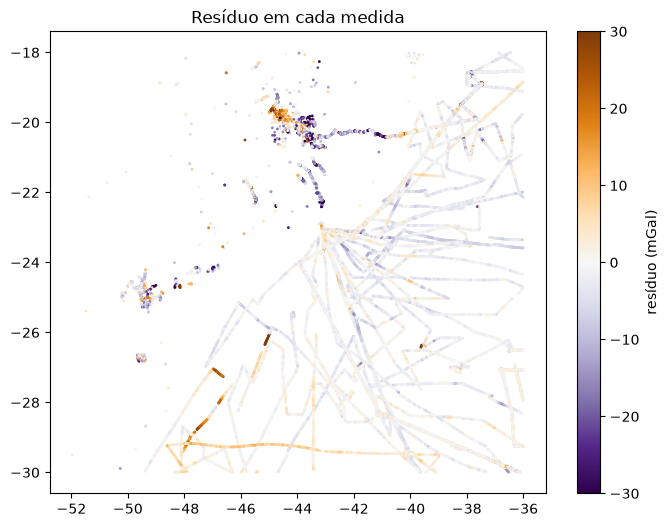

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(obs["lon"], obs["lat"], c=obs["r"], s=1, cmap="PuOr_r", vmin=-30, vmax=30)
fig.colorbar(sc, label="resíduo (mGal)")
ax.set_title("Resíduo em cada medida")
plt.show()

In [18]:
print("menor distância: %.3f graus (~%.0f km)" % (dist.min(), dist.min() * 111))
print("mediana:         %.3f graus (~%.0f km)" % (np.median(dist), np.median(dist) * 111))

menor distância: 0.011 graus (~1 km)
mediana:         0.854 graus (~95 km)


## Para a próxima conversa

Anote o que você viu (ou o que estranhou). O próximo notebook responde: **o resíduo de um ponto ajuda a prever o do vizinho?** Esse é o semivariograma, a peça central da fusão.